# 04. Item-Based Collaborative Filtering

В этом notebook мы переходим от признаков самих фильмов к collaborative filtering: модель смотрит не на жанры, а на совместное поведение пользователей.

## Что изучим

- что такое item-based collaborative filtering;
- как строится похожесть между фильмами по совместным positive interactions;
- как использовать историю пользователя для персональных рекомендаций;
- чем collaborative filtering отличается от content-based подхода;
- как честно сравнить item-based collaborative filtering с popularity baseline.


## Интуиция

Если content-based модель спрашивает: "похожи ли фильмы по признакам?", то collaborative filtering спрашивает: "нравились ли эти фильмы одним и тем же пользователям?"

Для item-based collaborative filtering это означает:

- каждый фильм описывается не жанрами, а паттерном пользовательских взаимодействий;
- похожими считаются фильмы, которые часто встречаются в историях одних и тех же пользователей;
- рекомендации строятся через фильмы, которые пользователь уже оценил положительно.

Это уже closer to recsys-классике: модель использует структуру поведения, а не только metadata объектов.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero


In [2]:
from recsys_basics.basic.item_item import ItemBasedCollaborativeRecommender
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import build_explicit_interactions, get_movielens_data_dir, load_movielens_frames
from recsys_basics.split import assert_no_user_time_leakage, leave_last_one_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10

frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
movies_df = frames.movies.rename(columns={"movieId": "item_id"}).copy()
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)

split_result = leave_last_one_out_split(positive_df, min_user_interactions=2)
train_df = split_result.train
test_df = split_result.test
assert_no_user_time_leakage(train_df, test_df)

seen_items_map = build_seen_items_map(train_df)
user_histories = (
    train_df.sort_values(["user_id", "timestamp", "item_id"])
    .groupby("user_id")["item_id"]
    .agg(list)
    .to_dict()
)

print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Users in evaluation: {len(user_histories):,}")


Train rows: 47,971
Test rows: 608
Users in evaluation: 608


## На каких данных учится item-based модель

Мы снова используем только positive interactions из `MovieLens`: оценки `>= 4.0`.

Но теперь важны не жанры, а матрица `user-item`:

- строки: пользователи;
- столбцы: фильмы;
- значение: был ли у пользователя положительный сигнал по фильму.

Если два фильма часто встречаются у одних и тех же пользователей, их похожесть становится выше.


In [3]:
training_summary = pd.DataFrame(
    {
        "metric": [
            "positive_train_rows",
            "train_users",
            "train_items",
            "avg_history_length",
            "median_history_length",
        ],
        "value": [
            len(train_df),
            train_df["user_id"].nunique(),
            train_df["item_id"].nunique(),
            train_df.groupby("user_id").size().mean(),
            train_df.groupby("user_id").size().median(),
        ],
    }
)
display(training_summary)
display(train_df.head())


,metric,value
0,positive_train_rows,"47,971.0000"
1,train_users,608.0000
2,train_items,"6,263.0000"
3,avg_history_length,78.8997
4,median_history_length,39.0000


,user_id,item_id,rating,timestamp,event
0,1,804,4.0000,2000-07-30 18:08:19+00:00,positive_rating
1,1,1210,5.0000,2000-07-30 18:08:19+00:00,positive_rating
2,1,2018,5.0000,2000-07-30 18:08:43+00:00,positive_rating
3,1,2628,4.0000,2000-07-30 18:08:43+00:00,positive_rating
4,1,2826,4.0000,2000-07-30 18:08:43+00:00,positive_rating


## Обучаем item-based collaborative filtering

Модель строит cosine similarity между фильмами по их пользовательским паттернам.

Интерпретация простая:

- если два фильма любят одни и те же пользователи, similarity растёт;
- если аудитории почти не пересекаются, similarity падает;
- рекомендации для пользователя строятся через фильмы, похожие на его историю.


In [4]:
item_based_model = ItemBasedCollaborativeRecommender().fit(train_df)

model_summary = pd.DataFrame(
    {
        "metric": ["users_in_matrix", "items_in_matrix"],
        "value": [len(item_based_model.user_to_index_), len(item_based_model.item_to_index_)],
    }
)
display(model_summary)


,metric,value
0,users_in_matrix,608
1,items_in_matrix,6263


## Интуитивная проверка: похожие фильмы по совместным пользователям

Сначала убедимся, что модель находит вменяемые соседства между фильмами. Это важный sanity-check перед рекомендациями.


In [5]:
anchor_title = "Toy Story (1995)"
anchor_item_id = int(movies_df.loc[movies_df["title"] == anchor_title, "item_id"].iloc[0])

similar_items_df = item_based_model.get_similar_items(anchor_item_id, k=10).merge(
    movies_df[["item_id", "title", "genres"]],
    on="item_id",
    how="left",
)

print(f"Anchor movie: {anchor_title} | item_id={anchor_item_id}")
display(similar_items_df)


Anchor movie: Toy Story (1995) | item_id=1


,item_id,similarity,title,genres
0,3114,0.4985,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
1,260,0.4560,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
2,2762,0.4444,"Sixth Sense, The (1999)",Drama|Horror|Mystery
3,480,0.4399,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
4,364,0.4384,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX
5,588,0.4345,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical
6,318,0.4309,"Shawshank Redemption, The (1994)",Crime|Drama
7,1265,0.4293,Groundhog Day (1993),Comedy|Fantasy|Romance
8,356,0.4251,Forrest Gump (1994),Comedy|Drama|Romance|War
9,1196,0.4225,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi


## Персональные рекомендации

Теперь используем историю пользователя. Для каждого фильма из его `train`-истории модель находит похожие фильмы, затем суммирует similarity scores и исключает already seen items.

Это уже полноценная персонализация на основе совместного поведения.


In [6]:
item_based_recommendations_df = item_based_model.recommend_many(
    user_histories=user_histories,
    seen_items_map=seen_items_map,
    k=TOP_K,
)

popularity_model = PopularityRecommender().fit(train_df)
popularity_recommendations_df = popularity_model.recommend_many(
    user_ids=sorted(user_histories.keys()),
    seen_items_map=seen_items_map,
    k=TOP_K,
)

all_user_ids = sorted(list(user_histories.keys()))
user_hit_flags = []
for user_id in all_user_ids:
    test_item_id = int(test_df.loc[test_df["user_id"] == user_id, "item_id"].iloc[0])
    cf_recs = item_based_model.recommend(
        history_item_ids=user_histories[int(user_id)],
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    popularity_recs = popularity_model.recommend(
        user_id=int(user_id),
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    user_hit_flags.append(
        {
            "user_id": int(user_id),
            "test_item_id": test_item_id,
            "item_based_hit_at_10": test_item_id in cf_recs,
            "popularity_hit_at_10": test_item_id in popularity_recs,
        }
    )

user_hit_flags_df = pd.DataFrame(user_hit_flags)
sample_hit_users = user_hit_flags_df[user_hit_flags_df["item_based_hit_at_10"]]["user_id"].head(2).tolist()
sample_miss_users = user_hit_flags_df[~user_hit_flags_df["item_based_hit_at_10"]]["user_id"].head(3).tolist()
sample_user_ids = sample_hit_users + sample_miss_users

sample_rows = []
for user_id in sample_user_ids:
    test_item_id = int(test_df.loc[test_df["user_id"] == user_id, "item_id"].iloc[0])
    cf_recs = item_based_model.recommend(
        history_item_ids=user_histories[int(user_id)],
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    popularity_recs = popularity_model.recommend(
        user_id=int(user_id),
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    sample_rows.append(
        {
            "user_id": int(user_id),
            "history_length": len(user_histories[int(user_id)]),
            "test_item_id": test_item_id,
            "item_based_hit_at_10": test_item_id in cf_recs,
            "popularity_hit_at_10": test_item_id in popularity_recs,
            "item_item_recommendations": cf_recs,
        }
    )

sample_recommendations_df = pd.DataFrame(sample_rows)
display(sample_recommendations_df)


,user_id,history_length,test_item_id,item_based_hit_at_10,popularity_hit_at_10,item_item_recommendations
0,12,23,39,True,False,"[597, 1569, 4246, 39, 356, 1307, 1028, 914, 17..."
1,54,2,356,True,True,"[296, 356, 527, 50, 47, 2959, 2571, 858, 110, ..."
2,1,199,2492,False,False,"[2918, 858, 296, 1036, 589, 2762, 1200, 1221, ..."
3,2,18,80489,False,False,"[2959, 99114, 91529, 69122, 2571, 7153, 33794,..."
4,3,15,3024,False,False,"[2985, 1129, 3527, 2901, 2529, 3697, 3740, 503..."


In [7]:
def hit_rate_at_k(test_interactions: pd.DataFrame, recommendations: pd.DataFrame, k: int) -> float:
    top_k = recommendations[recommendations["rank"] <= k]
    merged = test_interactions[["user_id", "item_id"]].merge(
        top_k,
        on=["user_id", "item_id"],
        how="left",
    )
    return float(merged["rank"].notna().mean())


def catalog_coverage(recommendations: pd.DataFrame, catalog_item_ids: pd.Series) -> float:
    if len(catalog_item_ids) == 0:
        return 0.0
    return float(recommendations["item_id"].nunique() / catalog_item_ids.nunique())


item_based_hit_rate_10 = hit_rate_at_k(test_df, item_based_recommendations_df, k=TOP_K)
popularity_hit_rate_10 = hit_rate_at_k(test_df, popularity_recommendations_df, k=TOP_K)
item_based_coverage = catalog_coverage(item_based_recommendations_df, train_df["item_id"])
popularity_coverage = catalog_coverage(popularity_recommendations_df, train_df["item_id"])

comparison_df = pd.DataFrame(
    {
        "model": ["popularity baseline", "item-based collaborative filtering"],
        "HitRate@10": [f"{popularity_hit_rate_10:.2%}", f"{item_based_hit_rate_10:.2%}"],
        "catalog_coverage": [f"{popularity_coverage:.2%}", f"{item_based_coverage:.2%}"],
        "unique_recommended_items": [
            popularity_recommendations_df["item_id"].nunique(),
            item_based_recommendations_df["item_id"].nunique(),
        ],
    }
)
display(comparison_df)


,model,HitRate@10,catalog_coverage,unique_recommended_items
0,popularity baseline,3.95%,0.97%,61
1,item-based collaborative filtering,6.41%,7.09%,444


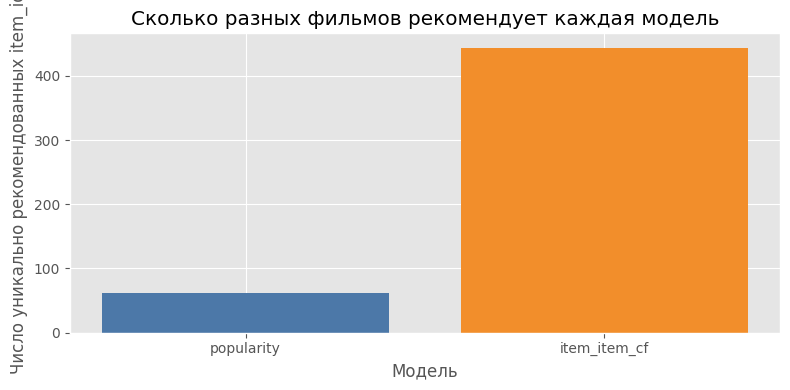

In [8]:
coverage_plot_df = pd.DataFrame(
    {
        "model": ["popularity baseline", "item-based collaborative filtering"],
        "unique_recommended_items": [
            popularity_recommendations_df["item_id"].nunique(),
            item_based_recommendations_df["item_id"].nunique(),
        ],
    }
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(coverage_plot_df["model"], coverage_plot_df["unique_recommended_items"], color=["#4C78A8", "#F28E2B"])
ax.set_title("Сколько разных фильмов рекомендует каждая модель")
ax.set_xlabel("Модель")
ax.set_ylabel("Число уникально рекомендованных item_id")
plt.tight_layout()
plt.show()


## Интерпретация результата

В этом запуске `item-based collaborative filtering` оказался сильнее `popularity baseline` по `HitRate@10`: `6.41%` против `3.95%`.

Это значит, что совместное поведение пользователей действительно дало полезный персонализирующий сигнал: модель чаще находит скрытый test-фильм, чем простой список самых популярных объектов.

Одновременно `item-based collaborative filtering` расширил покрытие каталога: `7.09%` против `0.97%`, а число уникально рекомендованных фильмов выросло с `61` до `444`.

Практический вывод здесь такой:

- `popularity baseline` остаётся сильной отправной точкой, но он слишком узкий и почти не персонализирует выдачу;
- `item-based collaborative filtering` уже использует структуру поведения пользователей и поэтому даёт заметный прирост качества;
- coverage у collaborative filtering выше, но он всё ещё не покрывает каталог так широко, как слабый content-based подход на жанрах;
- по сравнению с `03_content_based_tfidf.ipynb` collaborative filtering здесь выглядит убедительнее именно по качеству рекомендаций, а не только по разнообразию.

Для `MovieLens` это хороший учебный результат: collaborative сигнал оказался полезнее бедных item-features и дал уже не только персонализацию, но и выигрыш по quality metric.


## Ограничения метода

У item-based collaborative filtering тоже есть ограничения:

- новый фильм без взаимодействий почти невозможно рекомендовать;
- новый пользователь без истории тоже остаётся проблемой;
- качество зависит от плотности и чистоты interaction data;
- популярные фильмы часто получают больше надёжных соседей, чем нишевые;
- без аккуратного split легко получить leakage и завысить качество.


## Что получилось

После этого notebook должно быть понятно:

- как устроен item-based collaborative filtering;
- чем collaborative сигнал отличается от content-based признаков;
- как строится рекомендация через похожие объекты из истории пользователя;
- почему popularity baseline всё ещё нужен как точка отсчёта;
- какие ограничения и cold-start проблемы остаются у collaborative filtering.

## Что дальше

Следующий шаг: [05_metrics.ipynb](/Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/notebooks/basic/05_metrics.ipynb). Там мы аккуратно разберём, как оценивать recommender-модели и почему одного `HitRate@10` недостаточно.
